In [1]:
# In[1] — thread caps (fork-safety / reproducibility)
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'

In [2]:
# In[2] — imports, path, reload, confirm the passthrough is in your repo
import sys, os, importlib, warnings, inspect
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))
import numpy as np, pandas as pd
import seasonal_scan_harness as ssh
importlib.reload(ssh)
assert 'n_harmonics' in inspect.signature(ssh.run_one).parameters, "run_one passthrough missing"
assert {'forcings','n_harmonics'} <= set(inspect.signature(ssh.run_seasonal_scan).parameters), "scan passthrough missing"
print("passthrough OK |", ssh.SEASONAL_SOLVER_KWARGS)

passthrough OK | {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}


In [3]:
import numpy as np, seasonal_scan_harness as ssh
SELECT = 'Cloern both 1.62/2.48'      # ← config to load into the overview
FISH={'pre+recovery':0.5,'post':0.1}; ERAS=['pre+recovery','post']
MO=['J','F','M','A','M','J','J','A','S','O','N','D']; TGT=['mcs','pico','nano','micro','sumP']
spec=ssh.allometry('maranon_ward'); OBS=ssh.build_obs_targets(ERAS)
FORC=ssh.build_forcings(ERAS, hplc_coincident=False)
CFG={'Cloern both 1.62/2.48':(1.62,2.48),'OFF 1/1':(1.0,1.0),'Eppley grow 1.88/1':(1.88,1.0),'Cloern grow 1.62/1':(1.62,1.0)}  # (q10_grow, q10_graze)
def run(g,qg,qz):
    return ssh.run_one(spec,FORC[g],fish_rate=FISH[g],years=60,spinup=15,mP=0.0015,m_Z=0.10,
        grazing={'KsZ':0.23,'sigma_log':0.20},
        iv_overrides={'GrazingRouter':{'gge':0.31},'DetritusSink':{'w_sink':5.0},
                      'Growth':{'q10':qg},'Grazing':{'q10':qz}},
        n_harmonics=3,return_traj=True)[1]
def clim(r,k):
    keep=r['t']>=15*365; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365),'right')+1,1,12); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in range(1,13)])
def fit(r,g):
    k=r['t']>=15*365; mv={m:np.nanmean(r[m][k]) for m in TGT}; md={m:np.nanmedian(r[m][k]) for m in TGT}
    def rms(x,ov):
        t=[((x[m]-ov[m])/ov[m])**2 for m in TGT if ov.get(m) and abs(ov[m])>1e-9 and np.isfinite(x[m])]
        return np.sqrt(np.mean(t)) if t else np.nan
    return max(rms(mv,OBS[g]['mean']),rms(md,OBS[g]['med']))
od=OBS['post']['med']['Z200']-OBS['pre+recovery']['med']['Z200']; RUNS={}
print(f"Check 2 — temperature dependence @ baseline | obs med Z inv {od:+.4f}")
print(f"{'config qg/qz':>22}{'fit_pre':>8}{'fit_post':>9}{'post_ΣPmed':>11}{'post_maxP':>10}{'post_bl':>8}{'pre_bl':>7}{'Zmed_inv':>10}")
for lab,(qg,qz) in CFG.items():
    rp=run('pre+recovery',qg,qz); rq=run('post',qg,qz); RUNS[lab]={'pre+recovery':rp,'post':rq}
    kp,kq=rp['t']>=15*365, rq['t']>=15*365; cz,cp=clim(rq,'sumP'),clim(rp,'sumP')
    print(f"{lab:>22}{fit(rp,'pre+recovery'):>8.3f}{fit(rq,'post'):>9.3f}{np.nanmedian(rq['sumP'][kq]):>11.3f}"
          f"{np.nanmax(cz):>10.3f}{MO[int(np.nanargmax(cz))]:>8}{MO[int(np.nanargmax(cp))]:>7}"
          f"{np.nanmedian(rq['Z200'][kq])-np.nanmedian(rp['Z200'][kp]):>+10.4f}")
runs=RUNS[SELECT]; PICKLES=[f"temp {SELECT}"]; PICKLE_IDX=0
print(f"\nloaded '{SELECT}' into `runs` for the overview")

Check 2 — temperature dependence @ baseline | obs med Z inv +0.0035
          config qg/qz fit_pre fit_post post_ΣPmed post_maxP post_bl pre_bl  Zmed_inv
 Cloern both 1.62/2.48   0.228    0.167      0.388     0.956       A      M   +0.0026
               OFF 1/1   0.171    0.335      0.484     1.259       A      M   -0.0035
    Eppley grow 1.88/1   0.172    0.403      0.481     0.944       A      M   +0.0013
    Cloern grow 1.62/1   0.171    0.345      0.490     0.948       A      M   -0.0006

loaded 'Cloern both 1.62/2.48' into `runs` for the overview


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_34473/3965795697.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()


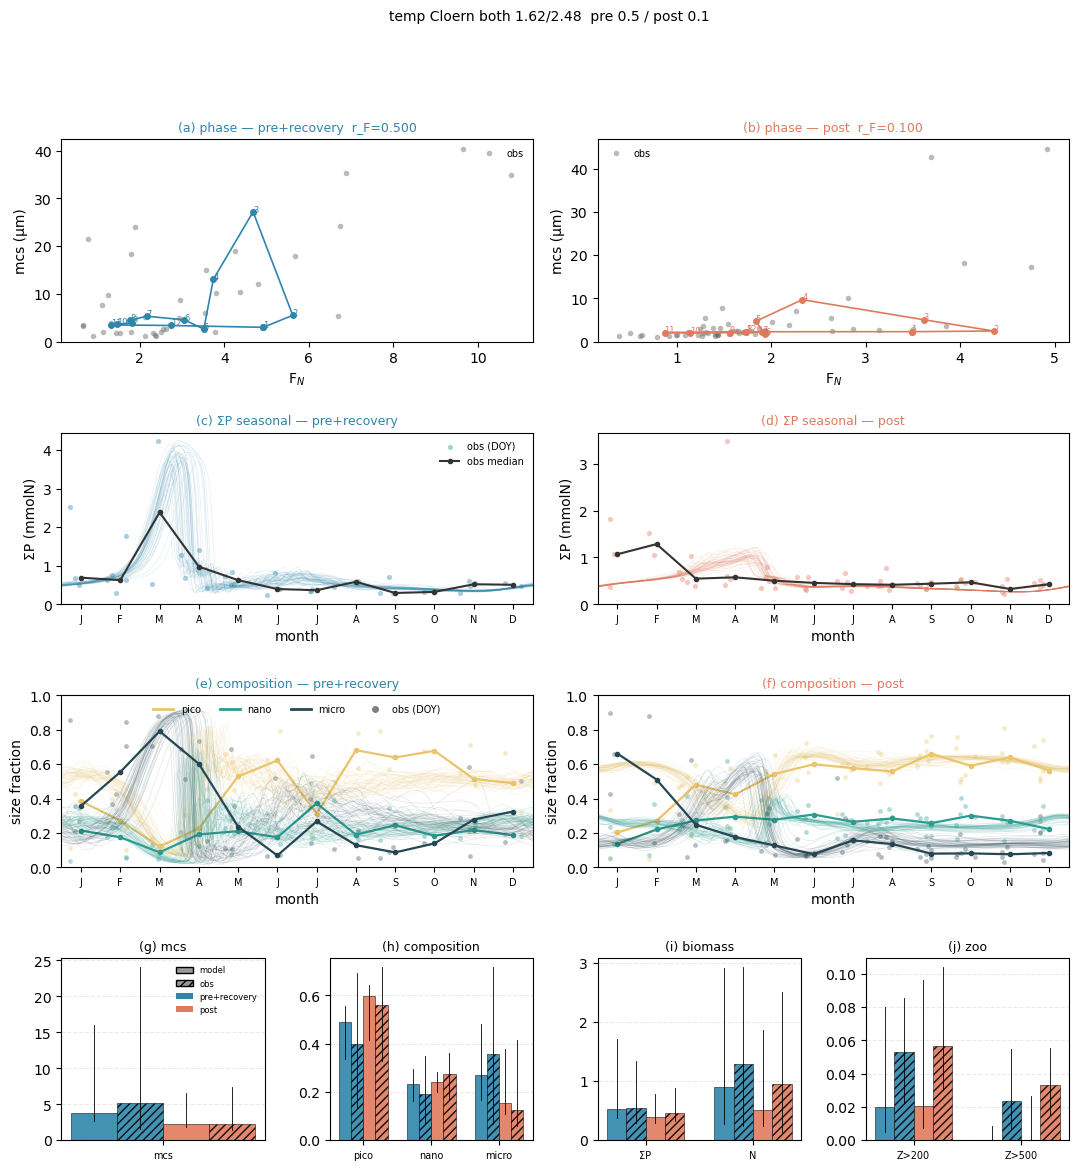

In [9]:
SEL = 'Cloern both 1.62/2.48'   # ← cycle: 'Cloern both 1.62/2.48' | 'OFF 1/1' | 'Eppley grow 1.88/1' | 'Cloern grow 1.62/1'
runs = RUNS[SEL]; FISH = {'pre+recovery':0.5,'post':0.1}; ERAS = ['pre+recovery','post']
PICKLES = [f"temp {SEL}  pre 0.5 / post 0.1"]; PICKLE_IDX = 0

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D; from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY
SPINUP=15; _MO=np.arange(1,13); MO=['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL={'pre+recovery':'#2E86AB','post':'#E07A5F'}; CLS=[('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m=ssh.build_obs_monthly(ERAS,forcing_complete=True)
def doy_to_mo(d): return np.interp(np.asarray(d,float),np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def ox(df,col='doy_hplc'):
    d=df[col] if col in df else pd.Series(np.nan,index=df.index)
    return np.where(np.isfinite(d),doy_to_mo(d),df['mo'])
def _clim(r,k):
    keep=r['t']>=SPINUP*365.0; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]; return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]; doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr): m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90]); ax.bar(x,np.median(v),w,color=c,alpha=.9,hatch=h,edgecolor='k',lw=.4,zorder=2); ax.plot([x,x],[lo,hi],color='k',lw=.6,zorder=4)
fig=plt.figure(figsize=(13,13)); gs=GridSpec(4,4,figure=fig,height_ratios=[1,.85,.85,.9],hspace=.5,wspace=.32)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]; fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c)
    om=obs_m[era].dropna(subset=['FN','mcs']); ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=.45,lw=0,label='obs')
    ax.set_xlabel('F$_N$'); ax.set_ylabel('mcs (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]; om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=.12,lw=.5)
    ax.scatter(ox(om),om['sumP'],s=14,color=c,alpha=.4,lw=0,label='obs (DOY)')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,np.max(allv)*1.05)
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN)'); ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=.12,lw=.5)
        o=om.dropna(subset=[cls]); ax.scatter(ox(o),o[cls],s=12,color=cc,alpha=.35,lw=0)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3)
    ax.set_xlim(.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction'); ax.set_title(f"({'ef'[ERAS.index(era)]}) composition — {era}",fontsize=9,color=ECOL[era])
    if col.start==0: ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],[c for c,_ in CLS]+['obs (DOY)'],fontsize=7,frameon=False,ncol=4,loc='upper center')
BP=[('(g) mcs',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-.5*W,('post','m'):.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]; _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7); ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=.25)
    if j==0: ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],['model','obs']+list(ERAS),fontsize=6,frameon=False)
fig.suptitle(f"{PICKLES[PICKLE_IDX]}",fontsize=10); plt.tight_layout(); plt.show()

In [3]:
# In[3] — HPLC-coincident 3h forcing + launch the r_F refit
def build_forcings_hplc(groups, csv=ssh.DEFAULT_CSV_PATH):
    df = pd.read_csv(csv, parse_dates=['date'])
    df['era'] = df['date'].dt.year.map(ssh.ERA_OF); df['mo'] = df['date'].dt.month
    df = df[df['micro_frac'].notna()]                         # HPLC-coincident cruises only
    def mm(eras, col):
        s = df[df['era'].isin(eras)].dropna(subset=[col]).groupby('mo')[col].mean().reindex(range(1, 13))
        return s.interpolate(limit_direction='both').values
    return {g: dict(fn=mm(ssh.GROUP_ERAS[g], 'FN_mmolN_m2_d'),
                    de=mm(ssh.GROUP_ERAS[g], 'depth_cutoff'),
                    t =mm(ssh.GROUP_ERAS[g], 'Temp_C')) for g in groups}

FORC_HPLC = build_forcings_hplc(['pre+recovery', 'post'])
R_F = np.linspace(0.05, 0.6, 30)
print(f"r_F: {R_F[0]:.2f}–{R_F[-1]:.2f}, n={len(R_F)} → {len(R_F)*2} runs")

res = ssh.run_seasonal_scan(
    constructs=['maranon_ward'], groups=['pre+recovery', 'post'], fish_rates=list(R_F),
    param_grid={'GGE': [0.31], 'mP': [0.0015], 'm_Z': [0.10], 'KsZ': [0.23], 'sigma_log': [0.20]},
    years=60, spinup=15,
    forcings=FORC_HPLC, n_harmonics=3,                        # ← the two new kwargs
    save_path='seasonal_rF_sweep_hplc3h_2026-06-27.pkl',
    processes=None, maxtasksperchild=1)
print(res.table(sort='score').round(3).to_string(index=False))

r_F: 0.05–0.60, n=30 → 60 runs
[seasonal scan] 60 runs: ['maranon_ward'] x ['pre+recovery', 'post'] x fish=[np.float64(0.05), np.float64(0.06896551724137931), np.float64(0.08793103448275862), np.float64(0.10689655172413792), np.float64(0.12586206896551722), np.float64(0.14482758620689654), np.float64(0.16379310344827586), np.float64(0.18275862068965515), np.float64(0.20172413793103444), np.float64(0.22068965517241373), np.float64(0.23965517241379308), np.float64(0.2586206896551724), np.float64(0.27758620689655167), np.float64(0.29655172413793096), np.float64(0.3155172413793103), np.float64(0.3344827586206896), np.float64(0.3534482758620689), np.float64(0.3724137931034482), np.float64(0.3913793103448275), np.float64(0.41034482758620683), np.float64(0.4293103448275861), np.float64(0.4482758620689654), np.float64(0.46724137931034476), np.float64(0.48620689655172405), np.float64(0.5051724137931034), np.float64(0.5241379310344827), np.float64(0.543103448275862), np.float64(0.562068965517241

In [4]:
# In[4] — run AFTER the scan: joint pairs + bloom timing + the Z>200 inversion test
MO = ['J','F','M','A','M','J','J','A','S','O','N','D']
recs = res.records                                            # records keep the clim_* arrays
def bloom_mo(rec):                                            # ΣP peak month from stored monthly clim
    c = np.asarray(rec.get('clim_sumP', [np.nan]*12), float)
    return int(np.nanargmax(c)) + 1 if np.isfinite(c).any() else np.nan
for r in recs: r['bloom_mo'] = bloom_mo(r)

pre  = pd.DataFrame([r for r in recs if r['group']=='pre+recovery']).sort_values('fish')
post = pd.DataFrame([r for r in recs if r['group']=='post']).sort_values('fish')
J = []
for _, p in pre.iterrows():
    for _, q in post.iterrows():
        if q['fish'] > p['fish']: continue
        J.append(dict(pre_fish=p['fish'], post_fish=q['fish'], joint=max(p['score'], q['score']),
                      post_bloom_mo=q['bloom_mo'],
                      post_bloom=MO[int(q['bloom_mo'])-1] if np.isfinite(q['bloom_mo']) else '·',
                      pre_bloom=MO[int(p['bloom_mo'])-1] if np.isfinite(p['bloom_mo']) else '·',
                      post_Z200=q['Z200'], pre_Z200=p['Z200'], Z200_inv=q['Z200']-p['Z200'],
                      post_micro=q['micro'], post_mcs_med=q['mcs_med']))
J = pd.DataFrame(J).sort_values('joint').reset_index(drop=True)
print("=== top 15 joint pairs (lower = better obs fit) ===")
print(J.head(15).round(3).to_string(index=False))

ok = J[J.Z200_inv > 0]                                        # inversion (post>pre Z200) kept
print(f"\npairs keeping the Z200 inversion: {len(ok)}/{len(J)}")
print("\nbest-scoring of those:");          print(ok.sort_values('joint').head(8).round(3).to_string(index=False))
print("\nearliest post bloom of those:");   print(ok.sort_values('post_bloom_mo').head(8).round(3).to_string(index=False))

=== top 15 joint pairs (lower = better obs fit) ===
 pre_fish  post_fish  joint  post_bloom_mo post_bloom pre_bloom  post_Z200  pre_Z200  Z200_inv  post_micro  post_mcs_med
    0.543      0.107  0.233              3          M         M      0.027     0.030    -0.003       0.193         2.470
    0.562      0.107  0.233              3          M         M      0.027     0.030    -0.002       0.193         2.470
    0.600      0.107  0.233              3          M         M      0.027     0.031    -0.003       0.193         2.470
    0.581      0.107  0.233              3          M         M      0.027     0.030    -0.002       0.193         2.470
    0.524      0.107  0.233              3          M         M      0.027     0.032    -0.004       0.193         2.470
    0.505      0.107  0.245              3          M         M      0.027     0.033    -0.006       0.193         2.470
    0.429      0.107  0.264              3          M         M      0.027     0.037    -0.010       

In [6]:
import importlib, numpy as np, seasonal_scan_harness as ssh
importlib.reload(ssh)
R_F = np.linspace(0.05, 0.6, 30)
res_all3h = ssh.run_seasonal_scan(
    constructs=['maranon_ward'], groups=['pre+recovery','post'], fish_rates=list(R_F),
    param_grid={'GGE':[0.31],'mP':[0.0015],'m_Z':[0.10],'KsZ':[0.23],'sigma_log':[0.20]},
    years=60, spinup=15,
    n_harmonics=3,                 # forcings=None → all-cruise build_forcings; 3 harmonics
    save_path='seasonal_rF_sweep_all3h_2026-06-27.pkl',
    processes=None, maxtasksperchild=1)
print(res_all3h.table(sort='score').round(3).to_string(index=False))

[seasonal scan] 60 runs: ['maranon_ward'] x ['pre+recovery', 'post'] x fish=[np.float64(0.05), np.float64(0.06896551724137931), np.float64(0.08793103448275862), np.float64(0.10689655172413792), np.float64(0.12586206896551722), np.float64(0.14482758620689654), np.float64(0.16379310344827586), np.float64(0.18275862068965515), np.float64(0.20172413793103444), np.float64(0.22068965517241373), np.float64(0.23965517241379308), np.float64(0.2586206896551724), np.float64(0.27758620689655167), np.float64(0.29655172413793096), np.float64(0.3155172413793103), np.float64(0.3344827586206896), np.float64(0.3534482758620689), np.float64(0.3724137931034482), np.float64(0.3913793103448275), np.float64(0.41034482758620683), np.float64(0.4293103448275861), np.float64(0.4482758620689654), np.float64(0.46724137931034476), np.float64(0.48620689655172405), np.float64(0.5051724137931034), np.float64(0.5241379310344827), np.float64(0.543103448275862), np.float64(0.5620689655172413), np.float64(0.58103448275862

In [7]:
import numpy as np, pandas as pd, seasonal_scan_harness as ssh
MO = ['J','F','M','A','M','J','J','A','S','O','N','D']
res = ssh.load_results('seasonal_rF_sweep_all3h_2026-06-27.pkl')   # or the hplc3h pickle
recs = res.records
def bloom(r):
    c = np.asarray(r.get('clim_sumP', [np.nan]*12), float)
    return int(np.nanargmax(c))+1 if np.isfinite(c).any() else np.nan
for r in recs: r['bloom_mo'] = bloom(r)
pre  = pd.DataFrame([r for r in recs if r['group']=='pre+recovery']).sort_values('fish')
post = pd.DataFrame([r for r in recs if r['group']=='post']).sort_values('fish')
o = res.obs                                          # build_obs_targets structure
oinv = o['post']['mean']['Z200'] - o['pre+recovery']['mean']['Z200']
print(f"OBS Z200 inversion (post-pre, mean): {oinv:+.4f}  "
      f"[post {o['post']['mean']['Z200']:.4f}, pre {o['pre+recovery']['mean']['Z200']:.4f}]")
J = []
for _, p in pre.iterrows():
    for _, q in post.iterrows():
        if q['fish'] > p['fish']: continue
        J.append(dict(pre_fish=p['fish'], post_fish=q['fish'], joint=max(p['score'], q['score']),
                      post_bloom=MO[int(q['bloom_mo'])-1] if np.isfinite(q['bloom_mo']) else '·',
                      Z200_inv=q['Z200']-p['Z200'], post_Z200=q['Z200'], pre_Z200=p['Z200']))
J = pd.DataFrame(J).sort_values('joint').reset_index(drop=True)
print("\ntop 12 joint pairs:"); print(J.head(12).round(3).to_string(index=False))
ok = J[J.Z200_inv > 0]
print(f"\ninversion-keeping pairs: {len(ok)}/{len(J)} | obs target inv = {oinv:+.4f}")
print(ok.sort_values('joint').head(8).round(3).to_string(index=False))

OBS Z200 inversion (post-pre, mean): +0.0128  [post 0.0660, pre 0.0533]

top 12 joint pairs:
 pre_fish  post_fish  joint post_bloom  Z200_inv  post_Z200  pre_Z200
    0.581      0.069  0.186          A     0.008      0.040     0.032
    0.581      0.088  0.186          A     0.006      0.038     0.032
    0.581      0.107  0.186          A     0.004      0.036     0.032
    0.581      0.126  0.186          A     0.002      0.034     0.032
    0.562      0.126  0.204          A     0.001      0.034     0.033
    0.562      0.107  0.204          A     0.003      0.036     0.033
    0.562      0.088  0.204          A     0.005      0.038     0.033
    0.562      0.069  0.204          A     0.007      0.040     0.033
    0.543      0.126  0.205          A     0.001      0.034     0.033
    0.543      0.107  0.205          A     0.003      0.036     0.033
    0.543      0.088  0.205          A     0.005      0.038     0.033
    0.543      0.069  0.205          A     0.007      0.040     0.0

In [11]:
# ── Seasonal scoring + flag layer (readout; no rescan) ──────────────────────
import numpy as np, pandas as pd, seasonal_scan_harness as ssh

PKL = 'seasonal_rF_sweep_all3h_2026-06-27.pkl'        # or the all3h pickle seasonal_rF_sweep_hplc3h_2026
res   = ssh.load_results(PKL)
recs  = res.records
OBS   = res.obs                                          # {group:{'med':..,'mean':..}}
GROUPS= sorted({r['group'] for r in recs})
obs_m = ssh.build_obs_monthly(GROUPS, forcing_complete=True)   # all-cruise, matches OBS

TGT  = ['mcs','pico','nano','micro','sumP']              # 5 targets; Z excluded; equal wt
CTOL, NCEIL, FRFLR, SPFLR = 0.15, 100.0, 0.02, 1e-6     # comp_tol / N-runaway / coexist / collapse
MO   = ['J','F','M','A','M','J','J','A','S','O','N','D']

def _pcts(v):
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    return np.percentile(v, [10, 90]) if v.size else (np.nan, np.nan)

obs_bloom = {}
for g in GROUPS:
    s = obs_m[g].dropna(subset=['sumP']).groupby('mo')['sumP'].median().reindex(range(1,13)).values
    obs_bloom[g] = int(np.nanargmax(s))+1 if np.isfinite(s).any() else np.nan
obs_env   = {g: {k: _pcts(obs_m[g][k]) for k in TGT} for g in GROUPS}     # obs 10–90% endpoints
obs_scale = {g: {k: OBS[g]['med'][k]  for k in TGT} for g in GROUPS}      # envelope normaliser

def central_score(r):
    g = r['group']
    def rms(getm, ov):
        t = [((getm(k)-ov[k])/ov[k])**2 for k in TGT
             if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(getm(k))]
        return float(np.sqrt(np.mean(t))) if t else np.nan
    scm = rms(lambda k: r.get(k, np.nan),        OBS[g]['mean'])
    scd = rms(lambda k: r.get(k+'_med', np.nan), OBS[g]['med'])
    return np.nanmax([scm, scd]), scm, scd

def envelope_score(r):
    g = r['group']; t = []
    for k in TGT:
        c = np.asarray(r.get('clim_'+k, [np.nan]*12), float); c = c[np.isfinite(c)]
        if c.size == 0: continue
        m10, m90 = np.percentile(c, [10, 90]); o10, o90 = obs_env[g][k]; sc = obs_scale[g][k]
        if not (np.isfinite(o10) and sc and abs(sc)>1e-9): continue
        t += [((m10-o10)/sc)**2, ((m90-o90)/sc)**2]
    return float(np.sqrt(np.mean(t))) if t else np.nan

def bloom_mo(r):
    c = np.asarray(r.get('clim_sumP', [np.nan]*12), float)
    return int(np.nanargmax(c))+1 if np.isfinite(c).any() else np.nan

def rec_flags(r):
    g = r['group']; om = OBS[g]['mean']; f = []
    if r.get('has_nan') or not (np.isfinite(r.get('sumP', np.nan)) and r['sumP'] > SPFLR): f.append('X')
    if np.isfinite(r.get('N', np.nan)) and r['N'] > NCEIL: f.append('N')
    cp = [np.nanmin(np.asarray(r.get('clim_'+k, [np.nan]*12), float)) for k in ('pico','nano','micro')]
    if np.isfinite(cp).any() and np.nanmin(cp) < FRFLR: f.append('c')
    if om.get('nano')  and np.isfinite(r.get('nano',  np.nan)) and r['nano']  > om['nano'] *(1+CTOL): f.append('n')
    if om.get('micro') and np.isfinite(r.get('micro', np.nan)) and r['micro'] < om['micro']*(1-CTOL): f.append('m')
    bm = bloom_mo(r); ob = obs_bloom[g]
    if not (np.isfinite(bm) and np.isfinite(ob) and abs(bm-ob) <= 1): f.append('b')
    return ''.join(f), bm

rows = []
for r in recs:
    sc, scm, scd = central_score(r); bm = bloom_mo(r); code, _ = rec_flags(r)
    rows.append(dict(group=r['group'], fish=r['fish'], score=sc, env=envelope_score(r),
                     mcs=r.get('mcs', np.nan), micro=r.get('micro', np.nan),
                     sumP=r.get('sumP', np.nan), Z200=r.get('Z200', np.nan),
                     N=r.get('N', np.nan), bloom=bm, flags=code))
A = pd.DataFrame(rows)

# sanity: recomputed COMPOSITION-only score must reproduce the stored score
def comp_only(r):
    g = r['group']; K = ['mcs','pico','nano','micro']
    def rms(getm, ov):
        t = [((getm(k)-ov[k])/ov[k])**2 for k in K if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(getm(k))]
        return np.sqrt(np.mean(t)) if t else np.nan
    return np.nanmax([rms(lambda k: r.get(k, np.nan), OBS[g]['mean']),
                      rms(lambda k: r.get(k+'_med', np.nan), OBS[g]['med'])])
dif = [abs(comp_only(r)-r['score']) for r in recs if np.isfinite(r.get('score', np.nan))]
print(f"PKL: {PKL}\nsanity: recomputed comp-only vs stored score, max|Δ|={max(dif):.2e} (≈0 expected)")
print(f"targets={TGT} (Z excluded, equal wt) | flags: X=collapse N=N-runaway c=coexist n=nano-over m=micro-short b=bloom>±1mo")
print("obs bloom month:", {g: MO[obs_bloom[g]-1] for g in GROUPS if np.isfinite(obs_bloom[g])})
for g in GROUPS:
    print(f"\n   obs 10–90% [{g}]:", {k: f"[{obs_env[g][k][0]:.3g},{obs_env[g][k][1]:.3g}]" for k in TGT})

for g in GROUPS:
    sub = A[A['group'] == g].sort_values('score')
    print(f"\n── {g} — best central score (any flags) ──")
    print(sub.head(8).round(3).to_string(index=False))
    clean = sub[sub['flags'] == '']          # bracket: .flags is a reserved pandas property
    print("   best CLEAN (no flags):")
    print("   " + (clean.head(3).round(3).to_string(index=False) if len(clean) else "none"))

PKL: seasonal_rF_sweep_all3h_2026-06-27.pkl
sanity: recomputed comp-only vs stored score, max|Δ|=5.55e-17 (≈0 expected)
targets=['mcs', 'pico', 'nano', 'micro', 'sumP'] (Z excluded, equal wt) | flags: X=collapse N=N-runaway c=coexist n=nano-over m=micro-short b=bloom>±1mo
obs bloom month: {'post': 'F', 'pre+recovery': 'M'}

   obs 10–90% [post]: {'mcs': '[1.42,7.39]', 'pico': '[0.326,0.715]', 'nano': '[0.168,0.36]', 'micro': '[0.0595,0.416]', 'sumP': '[0.332,0.889]'}

   obs 10–90% [pre+recovery]: {'mcs': '[1.62,24.1]', 'pico': '[0.133,0.692]', 'nano': '[0.0702,0.347]', 'micro': '[0.0682,0.717]', 'sumP': '[0.292,1.33]'}

── post — best central score (any flags) ──
group  fish  score   env   mcs  micro  sumP  Z200     N  bloom flags
 post 0.126  0.166 0.280 3.293  0.204 0.473 0.034 0.770      4     b
 post 0.107  0.172 0.451 3.188  0.190 0.469 0.036 0.777      4     b
 post 0.088  0.174 0.545 3.148  0.189 0.469 0.038 0.799      4     b
 post 0.069  0.175 0.461 3.141  0.185 0.471 0.040 0

In [12]:
oinv = OBS['post']['mean']['Z200'] - OBS['pre+recovery']['mean']['Z200']
print(f"obs Z200 inversion (post−pre, mean) = {oinv:+.4f}\n")
pre, post = A[A['group']=='pre+recovery'], A[A['group']=='post']
J = []
for _, p in pre.iterrows():
    for _, q in post.iterrows():
        if q.fish > p.fish: continue                       # collapse ⇒ fewer fish post
        zinv = q.Z200 - p.Z200
        J.append(dict(pre_rF=p.fish, post_rF=q.fish,
                      joint=float(np.nanmax([p.score, q.score])),
                      env=float(np.nanmax([p.env, q.env])),
                      pre_fl=p['flags'] or '·', post_fl=q['flags'] or '·',
                      Zdir='ok' if zinv > 0 else '–', Z200_inv=zinv,
                      post_bloom=MO[int(q.bloom)-1] if np.isfinite(q.bloom) else '·'))
J = pd.DataFrame(J)
print("top 10 pairs by joint score (any flags):")
print(J.sort_values('joint').head(10).round(3).to_string(index=False))
zk = J[J.Z200_inv > 0].sort_values('joint')
print(f"\npairs with Z200 inversion kept (Zdir ok): {len(zk)}/{len(J)}  | obs target {oinv:+.4f}")
print(zk.head(8).round(3).to_string(index=False) if len(zk) else "none")
cleanz = J[(J.pre_fl=='·') & (J.post_fl=='·') & (J.Z200_inv > 0)].sort_values('joint')
print(f"\nfully clean pairs AND Zdir ok: {len(cleanz)}")
print(cleanz.head(6).round(3).to_string(index=False) if len(cleanz) else "none")

obs Z200 inversion (post−pre, mean) = +0.0128

top 10 pairs by joint score (any flags):
 pre_rF  post_rF  joint   env pre_fl post_fl Zdir  Z200_inv post_bloom
  0.581    0.126  0.166 0.566      ·       b   ok     0.002          A
  0.581    0.107  0.172 0.566      ·       b   ok     0.004          A
  0.581    0.088  0.174 0.566      ·       b   ok     0.006          A
  0.581    0.069  0.175 0.566      ·       b   ok     0.008          A
  0.562    0.107  0.183 0.583      ·       b   ok     0.003          A
  0.562    0.126  0.183 0.583      ·       b   ok     0.001          A
  0.562    0.088  0.183 0.583      ·       b   ok     0.005          A
  0.562    0.069  0.183 0.583      ·       b   ok     0.007          A
  0.543    0.069  0.184 0.540      ·       b   ok     0.007          A
  0.543    0.088  0.184 0.545      ·       b   ok     0.005          A

pairs with Z200 inversion kept (Zdir ok): 46/465  | obs target +0.0128
 pre_rF  post_rF  joint   env pre_fl post_fl Zdir  Z200_inv


##############################################################################
## TOP joint (any flag):  pre_rF=0.581  post_rF=0.126
##############################################################################
   [repro pre+recovery r_F=0.581] re-run mcs=7.3889 vs stored 7.3889  |Δ|=3.33e-05  (≈0 ⇒ forcing+harmonics match)

[TOP joint (any flag) | pre+recovery | r_F=0.581]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           7.39      9.94       4.1      5.14   -0.26   -0.20
pico         0.438     0.418     0.475     0.399   +0.05   +0.19
nano          0.22      0.21     0.225     0.193   +0.05   +0.16
micro        0.342     0.372      0.29     0.357   -0.08   -0.19
sumP         0.792     0.748     0.538      0.55   +0.06   -0.02
N             1.14      1.51     0.757      1.29   -0.24   -0.41
PP           0.154     0.542     0.138      0.28   -0.72   -0.51
Export        2.16      3.52      2.11      2.64   -0.39   -0.20
Z200

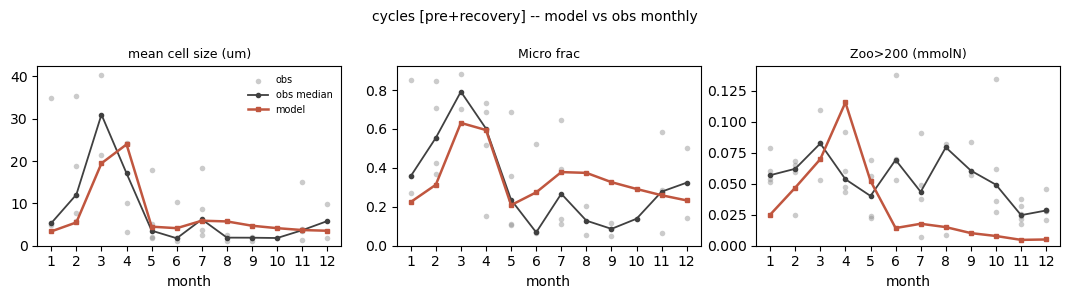

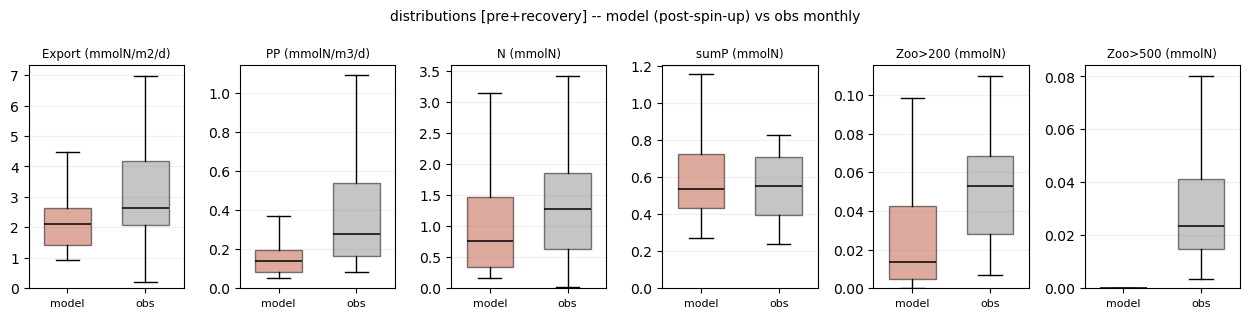

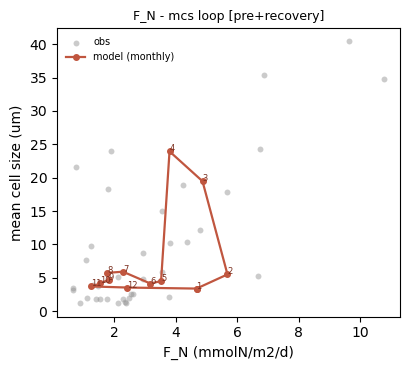

   [repro post r_F=0.126] re-run mcs=3.2928 vs stored 3.2928  |Δ|=4.44e-13  (≈0 ⇒ forcing+harmonics match)

[TOP joint (any flag) | post | r_F=0.126]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           3.29      4.67      2.31      2.32   -0.29   -0.00
pico         0.557     0.542     0.591     0.562   +0.03   +0.05
nano         0.239     0.267     0.238     0.272   -0.10   -0.13
micro        0.204     0.191     0.154     0.124   +0.07   +0.24
sumP         0.473     0.581     0.391     0.459   -0.19   -0.15
N             0.77      1.23     0.507     0.959   -0.38   -0.47
PP           0.114     0.324    0.0951     0.202   -0.65   -0.53
Export           2      2.67      1.76      2.17   -0.25   -0.19
Z200        0.0339     0.066    0.0187    0.0566   -0.49   -0.67
Z500        0.0067    0.0371  1.86e-05    0.0334   -0.82   -1.00
score   mean=0.160  med=0.138  joint(max)=0.160   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False n

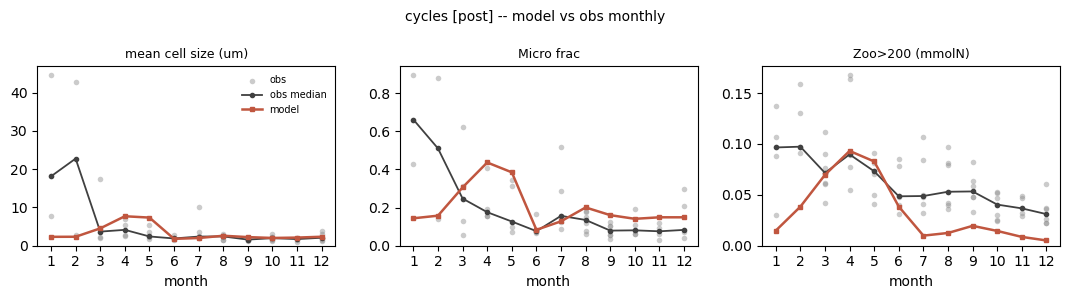

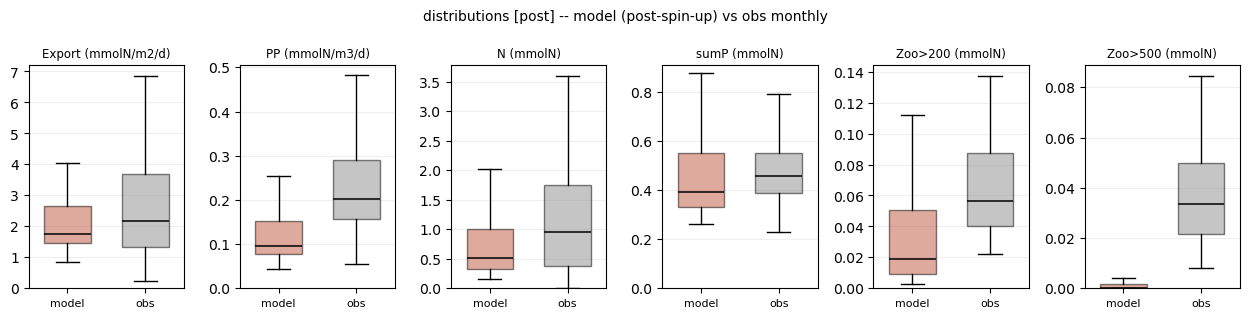

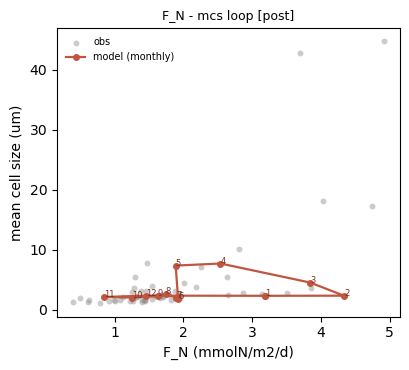


##############################################################################
## TOP Zdir-ok:  pre_rF=0.581  post_rF=0.126
##############################################################################
   [repro pre+recovery r_F=0.581] re-run mcs=7.3889 vs stored 7.3889  |Δ|=3.33e-05  (≈0 ⇒ forcing+harmonics match)

[TOP Zdir-ok | pre+recovery | r_F=0.581]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           7.39      9.94       4.1      5.14   -0.26   -0.20
pico         0.438     0.418     0.475     0.399   +0.05   +0.19
nano          0.22      0.21     0.225     0.193   +0.05   +0.16
micro        0.342     0.372      0.29     0.357   -0.08   -0.19
sumP         0.792     0.748     0.538      0.55   +0.06   -0.02
N             1.14      1.51     0.757      1.29   -0.24   -0.41
PP           0.154     0.542     0.138      0.28   -0.72   -0.51
Export        2.16      3.52      2.11      2.64   -0.39   -0.20
Z200        0.0319    

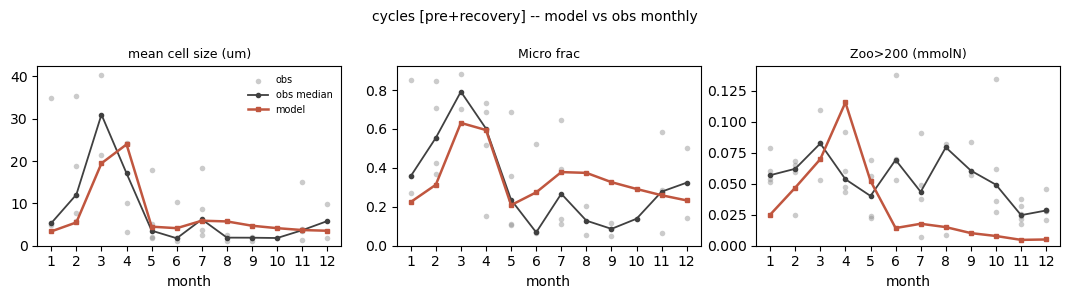

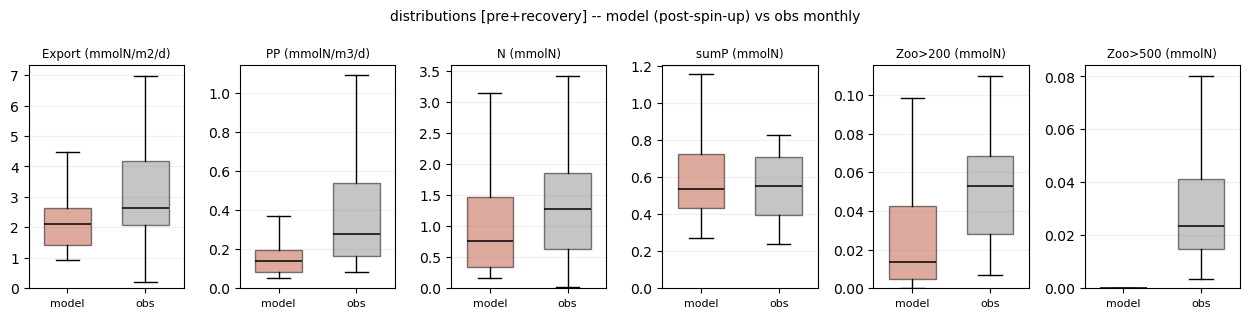

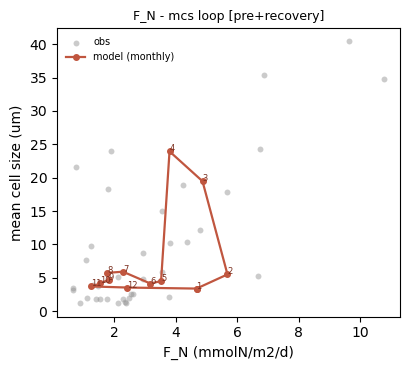

   [repro post r_F=0.126] re-run mcs=3.2928 vs stored 3.2928  |Δ|=4.44e-13  (≈0 ⇒ forcing+harmonics match)

[TOP Zdir-ok | post | r_F=0.126]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           3.29      4.67      2.31      2.32   -0.29   -0.00
pico         0.557     0.542     0.591     0.562   +0.03   +0.05
nano         0.239     0.267     0.238     0.272   -0.10   -0.13
micro        0.204     0.191     0.154     0.124   +0.07   +0.24
sumP         0.473     0.581     0.391     0.459   -0.19   -0.15
N             0.77      1.23     0.507     0.959   -0.38   -0.47
PP           0.114     0.324    0.0951     0.202   -0.65   -0.53
Export           2      2.67      1.76      2.17   -0.25   -0.19
Z200        0.0339     0.066    0.0187    0.0566   -0.49   -0.67
Z500        0.0067    0.0371  1.86e-05    0.0334   -0.82   -1.00
score   mean=0.160  med=0.138  joint(max)=0.160   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0

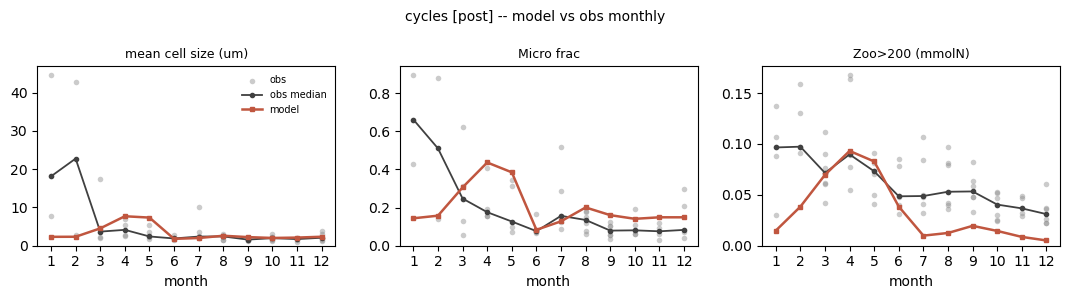

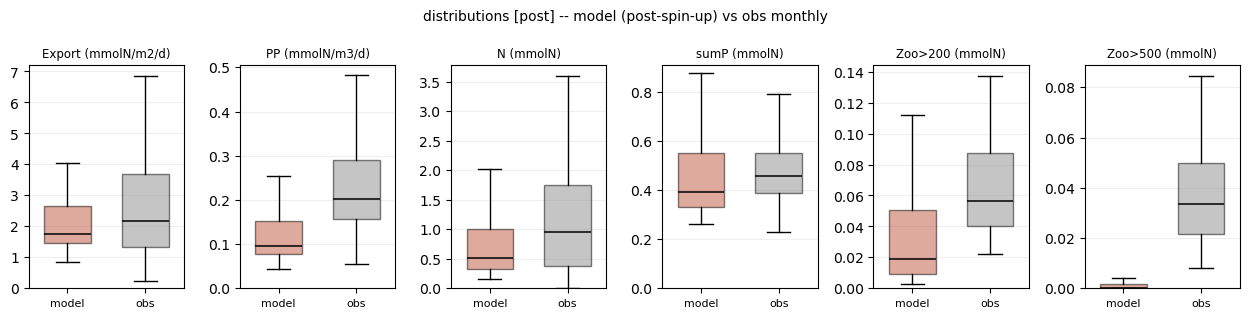

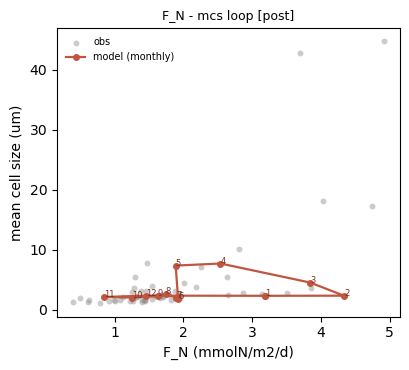


### TOP clean & Zdir-ok: no such pair in this pickle

##############################################################################
## committed ref 0.5/0.1:  pre_rF=0.500  post_rF=0.100
##############################################################################

[committed ref 0.5/0.1 | pre+recovery | r_F=0.500]
=== diagnose [pre+recovery] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           6.65      9.94      3.71      5.14   -0.33   -0.28
pico          0.46     0.418     0.492     0.399   +0.10   +0.23
nano         0.227      0.21     0.229     0.193   +0.08   +0.18
micro        0.313     0.372     0.265     0.357   -0.16   -0.26
sumP         0.766     0.748      0.52      0.55   +0.02   -0.05
N             1.19      1.51     0.847      1.29   -0.21   -0.34
PP           0.157     0.542     0.143      0.28   -0.71   -0.49
Export        2.26      3.52      2.25      2.64   -0.36   -0.15
Z200        0.0363    0.0533     0.017     0.053   -0.32   -0.6

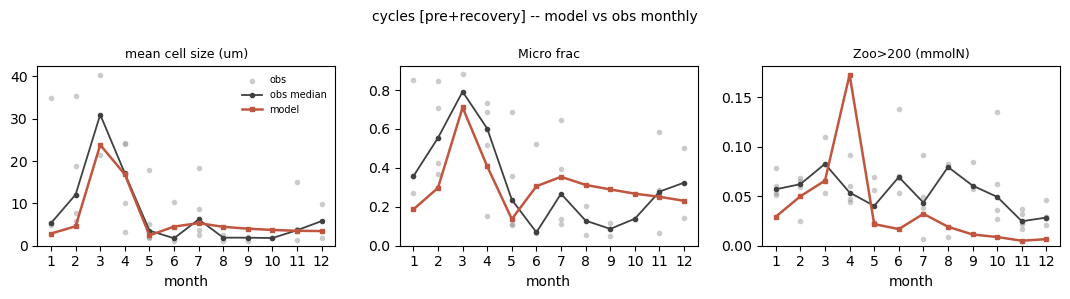

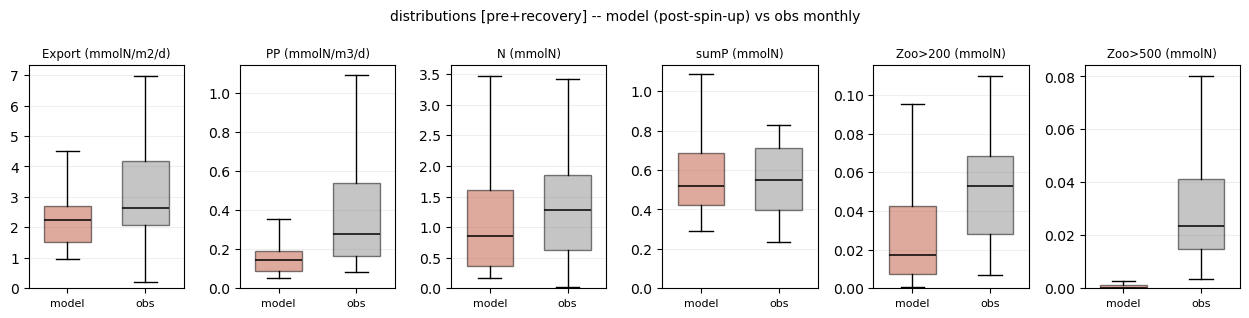

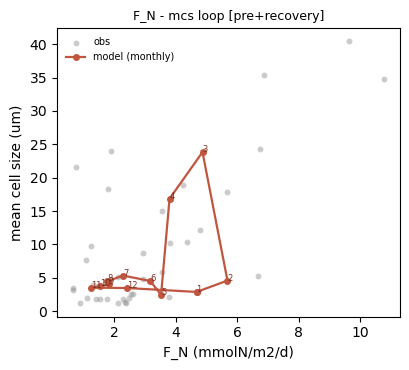


[committed ref 0.5/0.1 | post | r_F=0.100]
=== diagnose [post] ===
metric    mod_mean  obs_mean   mod_med   obs_med  d_mean   d_med
mcs           3.22      4.67      2.22      2.32   -0.31   -0.04
pico         0.564     0.542     0.599     0.562   +0.04   +0.07
nano         0.244     0.267     0.244     0.272   -0.09   -0.10
micro        0.193     0.191     0.146     0.124   +0.01   +0.18
sumP         0.472     0.581     0.388     0.459   -0.19   -0.15
N            0.787      1.23     0.509     0.959   -0.36   -0.47
PP           0.114     0.324    0.0969     0.202   -0.65   -0.52
Export        2.03      2.67      1.81      2.17   -0.24   -0.17
Z200        0.0366     0.066    0.0205    0.0566   -0.45   -0.64
Z500       0.00838    0.0371   3.2e-05    0.0334   -0.77   -1.00
score   mean=0.163  med=0.109  joint(max)=0.163   (on ['mcs', 'pico', 'nano', 'micro'])
flags   has_nan=False nan_frac=0.00 mcs_conv=1.00 Z200_peak=0.106 cv_sumP=0.45
        floor   minP=0.0000  minZ=0.0000   (post-s

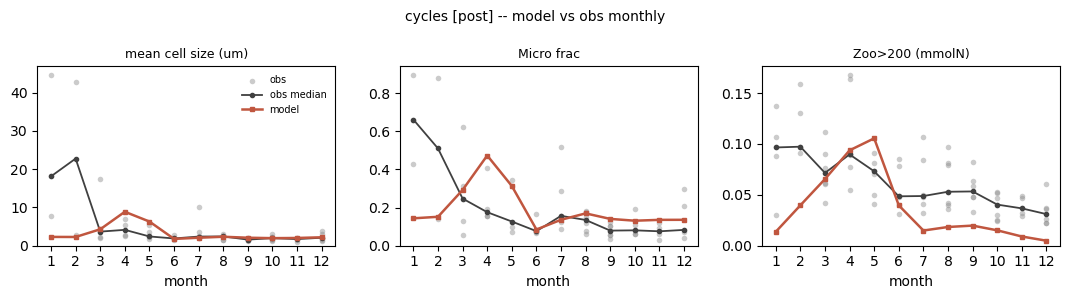

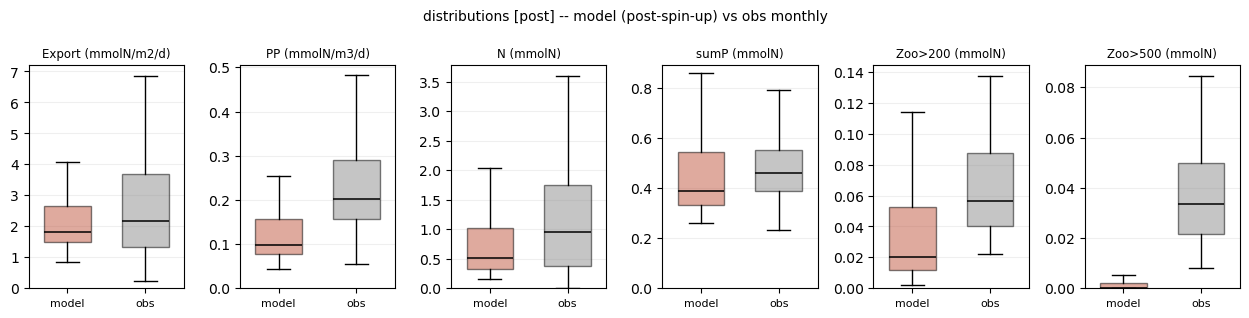

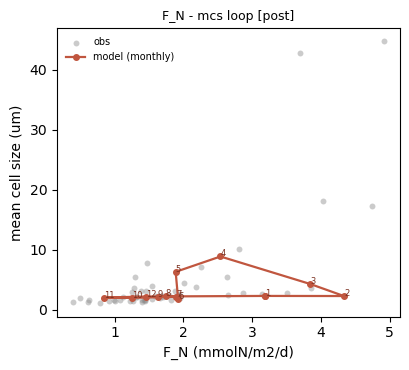

In [13]:
import seasonal_diagnostics as sd, importlib; importlib.reload(sd)
# Run AFTER Cell A + Cell B on the pickle you want to inspect (needs res, A, J in scope).

N_HARM = 3                         # MUST match the scan launch; not stored in the pickle
spec   = ssh.allometry('maranon_ward')
FORC   = res.forcings              # EXACT per-era forcing the pickle used (HPLC-coinc OR all-cruise)
OBS_T  = res.obs                   # stored obs targets (med+mean)
OBS_M  = ssh.build_obs_monthly(['pre+recovery', 'post'], forcing_complete=True)

def _run(group, fish):
    return ssh.run_one(spec, FORC[group], fish_rate=float(fish), years=60, spinup=15,
                       mP=0.0015, m_Z=0.10, grazing={'KsZ': 0.23, 'sigma_log': 0.20},
                       iv_overrides={'GrazingRouter': {'gge': 0.31}},
                       n_harmonics=N_HARM, return_traj=True)

def _firstpair(df):
    return (float(df.iloc[0].pre_rF), float(df.iloc[0].post_rF)) if len(df) else (np.nan, np.nan)

Jj  = J.sort_values('joint')
Jz  = J[J.Z200_inv > 0].sort_values('joint')
Jcz = J[(J.pre_fl == '·') & (J.post_fl == '·') & (J.Z200_inv > 0)].sort_values('joint')
CANDS = [
    ('TOP joint (any flag)', *_firstpair(Jj)),     # what the ranking surfaces first
    ('TOP Zdir-ok',          *_firstpair(Jz)),     # best inversion-keeping pair
    ('TOP clean & Zdir-ok',  *_firstpair(Jcz)),    # the "presentable" pair (may be absent)
    ('committed ref 0.5/0.1', 0.5, 0.1),           # incumbent; off-grid → repro-check skipped
]

def _stored(group, fish):
    sub = A[(A['group'] == group) & (np.abs(A.fish - float(fish)) < 1e-9)]
    return sub.iloc[0] if len(sub) else None

for tag, pf, qf in CANDS:
    if not (np.isfinite(pf) and np.isfinite(qf)):
        print(f"\n### {tag}: no such pair in this pickle"); continue
    print('\n' + '#'*78 + f"\n## {tag}:  pre_rF={pf:.3f}  post_rF={qf:.3f}\n" + '#'*78)
    for group, fish in [('pre+recovery', pf), ('post', qf)]:
        clim, r = _run(group, fish)
        s = _stored(group, fish)
        if s is not None:
            print(f"   [repro {group} r_F={fish:.3f}] re-run mcs={clim.get('mcs', np.nan):.4f} "
                  f"vs stored {s.mcs:.4f}  |Δ|={abs(clim.get('mcs', np.nan)-s.mcs):.2e}  (≈0 ⇒ forcing+harmonics match)")
        sd.diagnose(clim, r, group, spinup=15, obs_targets=OBS_T, obs_monthly=OBS_M,
                    title=f"\n[{tag} | {group} | r_F={fish:.3f}]")

In [23]:
# ═══ Fig-4 driver (CACHED): cycle pickle × ranking, flags filtered ═══════════
import importlib, numpy as np, pandas as pd, seasonal_scan_harness as ssh

PICKLES = ['seasonal_rF_sweep_hplc3h_2026-06-27.pkl',
           'seasonal_rF_sweep_all3h_2026-06-27.pkl']
PICKLE_IDX   = 0          # ← which file
RANK_IDX     = 0          # ← which pair within the filtered ranking
DROP_FLAGGED = True       # drop pairs with any record flag
REQUIRE_ZDIR = True       # keep only post>pre Z200
PREWARM      = True       # precompute every run in the shortlist now → browsing is instant
N_HARM       = 3          # MUST match the scan launch

FLAG_KEY = {'X':'collapse / NaN-terminated', 'N':'N runaway (>100)',
            'c':'coexistence loss (a size class ~vanishes)', 'n':'Nano over obs (>+15%)',
            'm':'Micro short of obs (<−15%)', 'b':'ΣP bloom > ±1 month from obs'}

try: _RES_CACHE, _RUN_CACHE                       # persist across re-runs of this cell
except NameError: _RES_CACHE, _RUN_CACHE = {}, {}
SPEC = ssh.allometry('maranon_ward')

def _rank(path):
    res = ssh.load_results(path); OBS = res.obs; GR = ['pre+recovery', 'post']
    om  = ssh.build_obs_monthly(GR, forcing_complete=True)
    TGT = ['mcs','pico','nano','micro','sumP']; CTOL,NCEIL,FRFLR,SPFLR = 0.15,100.,0.02,1e-6
    obb = {g: (int(np.nanargmax(om[g].dropna(subset=['sumP']).groupby('mo')['sumP']
                    .median().reindex(range(1,13)).values)+1) if om[g]['sumP'].notna().any() else np.nan) for g in GR}
    def csc(r):
        g=r['group']
        def rms(get,ov):
            t=[((get(k)-ov[k])/ov[k])**2 for k in TGT if ov.get(k) and abs(ov[k])>1e-9 and np.isfinite(get(k))]
            return float(np.sqrt(np.mean(t))) if t else np.nan
        return np.nanmax([rms(lambda k:r.get(k,np.nan),OBS[g]['mean']), rms(lambda k:r.get(k+'_med',np.nan),OBS[g]['med'])])
    def bmo(r):
        c=np.asarray(r.get('clim_sumP',[np.nan]*12),float); return int(np.nanargmax(c))+1 if np.isfinite(c).any() else np.nan
    def flg(r):
        g=r['group']; omn=OBS[g]['mean']; f=''
        if r.get('has_nan') or not(np.isfinite(r.get('sumP',np.nan)) and r['sumP']>SPFLR): f+='X'
        if np.isfinite(r.get('N',np.nan)) and r['N']>NCEIL: f+='N'
        cp=[np.nanmin(np.asarray(r.get('clim_'+k,[np.nan]*12),float)) for k in ('pico','nano','micro')]
        if np.isfinite(cp).any() and np.nanmin(cp)<FRFLR: f+='c'
        if omn.get('nano')  and np.isfinite(r.get('nano',  np.nan)) and r['nano'] >omn['nano'] *(1+CTOL): f+='n'
        if omn.get('micro') and np.isfinite(r.get('micro', np.nan)) and r['micro']<omn['micro']*(1-CTOL): f+='m'
        bm=bmo(r); ob=obb[g]
        if not(np.isfinite(bm) and np.isfinite(ob) and abs(bm-ob)<=1): f+='b'
        return f
    A=pd.DataFrame([dict(group=r['group'],fish=r['fish'],score=csc(r),Z200=r.get('Z200',np.nan),
                         flag=flg(r),bloom=bmo(r)) for r in res.records])
    pre,post=A[A.group=='pre+recovery'],A[A.group=='post']; J=[]
    for _,p in pre.iterrows():
        for _,q in post.iterrows():
            if q.fish>p.fish: continue
            J.append(dict(pre_rF=p.fish,post_rF=q.fish,joint=float(np.nanmax([p.score,q.score])),
                          pre_fl=p['flag'] or '·',post_fl=q['flag'] or '·',Zdir=bool(q.Z200-p.Z200>0),Z200_inv=q.Z200-p.Z200))
    return res, A, pd.DataFrame(J)

def _get(path):
    if path not in _RES_CACHE: _RES_CACHE[path]=_rank(path)
    return _RES_CACHE[path]
def _run_cached(path,group,fish):
    key=(path,group,round(float(fish),6),N_HARM)
    if key not in _RUN_CACHE:
        res=_get(path)[0]
        _RUN_CACHE[key]=ssh.run_one(SPEC,res.forcings[group],fish_rate=float(fish),years=60,spinup=15,
                                    mP=0.0015,m_Z=0.10,grazing={'KsZ':0.23,'sigma_log':0.20},
                                    iv_overrides={'GrazingRouter':{'gge':0.31}},n_harmonics=N_HARM,return_traj=True)
    return _RUN_CACHE[key]

PATH=PICKLES[PICKLE_IDX]; res,A,J=_get(PATH)
sel=J.copy()
if DROP_FLAGGED: sel=sel[(sel.pre_fl=='·')&(sel.post_fl=='·')]
if REQUIRE_ZDIR: sel=sel[sel.Zdir]
sel=sel.sort_values('joint').reset_index(drop=True)
print(f"pickle[{PICKLE_IDX}] {PATH}  | filtered pairs: {len(sel)} (DROP_FLAGGED={DROP_FLAGGED}, REQUIRE_ZDIR={REQUIRE_ZDIR})")
if len(sel)==0:
    print("  !! none survive — falling back to UNFILTERED joint ranking"); sel=J.sort_values('joint').reset_index(drop=True)
print("flag key: " + " | ".join(f"{k}={v}" for k,v in FLAG_KEY.items()))
print(sel.head(10).round(3).to_string())

if PREWARM:
    todo={('pre+recovery',round(float(r.pre_rF),6)) for _,r in sel.iterrows()} | \
         {('post',round(float(r.post_rF),6)) for _,r in sel.iterrows()}
    new=[(g,f) for (g,f) in todo if (PATH,g,f,N_HARM) not in _RUN_CACHE]
    if new:
        print(f"prewarming {len(new)} uncached runs ...",flush=True)
        for g,f in new: _run_cached(PATH,g,f)

row=sel.iloc[min(RANK_IDX,len(sel)-1)]; PF,QF=float(row.pre_rF),float(row.post_rF)
print(f"\n>>> RANK_IDX={RANK_IDX}:  pre_rF={PF:.3f}  post_rF={QF:.3f}  joint={row.joint:.3f}  "
      f"Z200_inv={row.Z200_inv:+.4f}  flags[{row.pre_fl}/{row.post_fl}]")
ERAS=['pre+recovery','post']; FISH={'pre+recovery':PF,'post':QF}
runs={g:_run_cached(PATH,g,FISH[g])[1] for g in ERAS}
print(f"cache: {len(_RUN_CACHE)} runs held ({sum(1 for k in _RUN_CACHE if k[0]==PATH)} for this pickle)")

pickle[0] seasonal_rF_sweep_hplc3h_2026-06-27.pkl  | filtered pairs: 7 (DROP_FLAGGED=True, REQUIRE_ZDIR=True)
flag key: X=collapse / NaN-terminated | N=N runaway (>100) | c=coexistence loss (a size class ~vanishes) | n=Nano over obs (>+15%) | m=Micro short of obs (<−15%) | b=ΣP bloom > ±1 month from obs
   pre_rF  post_rF  joint pre_fl post_fl  Zdir  Z200_inv
0   0.562    0.069  0.252      ·       ·  True     0.001
1   0.543    0.069  0.252      ·       ·  True     0.000
2   0.581    0.069  0.252      ·       ·  True     0.001
3   0.562    0.050  0.313      ·       ·  True     0.003
4   0.543    0.050  0.313      ·       ·  True     0.002
5   0.581    0.050  0.313      ·       ·  True     0.002
6   0.600    0.050  0.313      ·       ·  True     0.001
prewarming 6 uncached runs ...

>>> RANK_IDX=0:  pre_rF=0.562  post_rF=0.069  joint=0.252  Z200_inv=+0.0009  flags[·/·]
cache: 6 runs held (6 for this pickle)


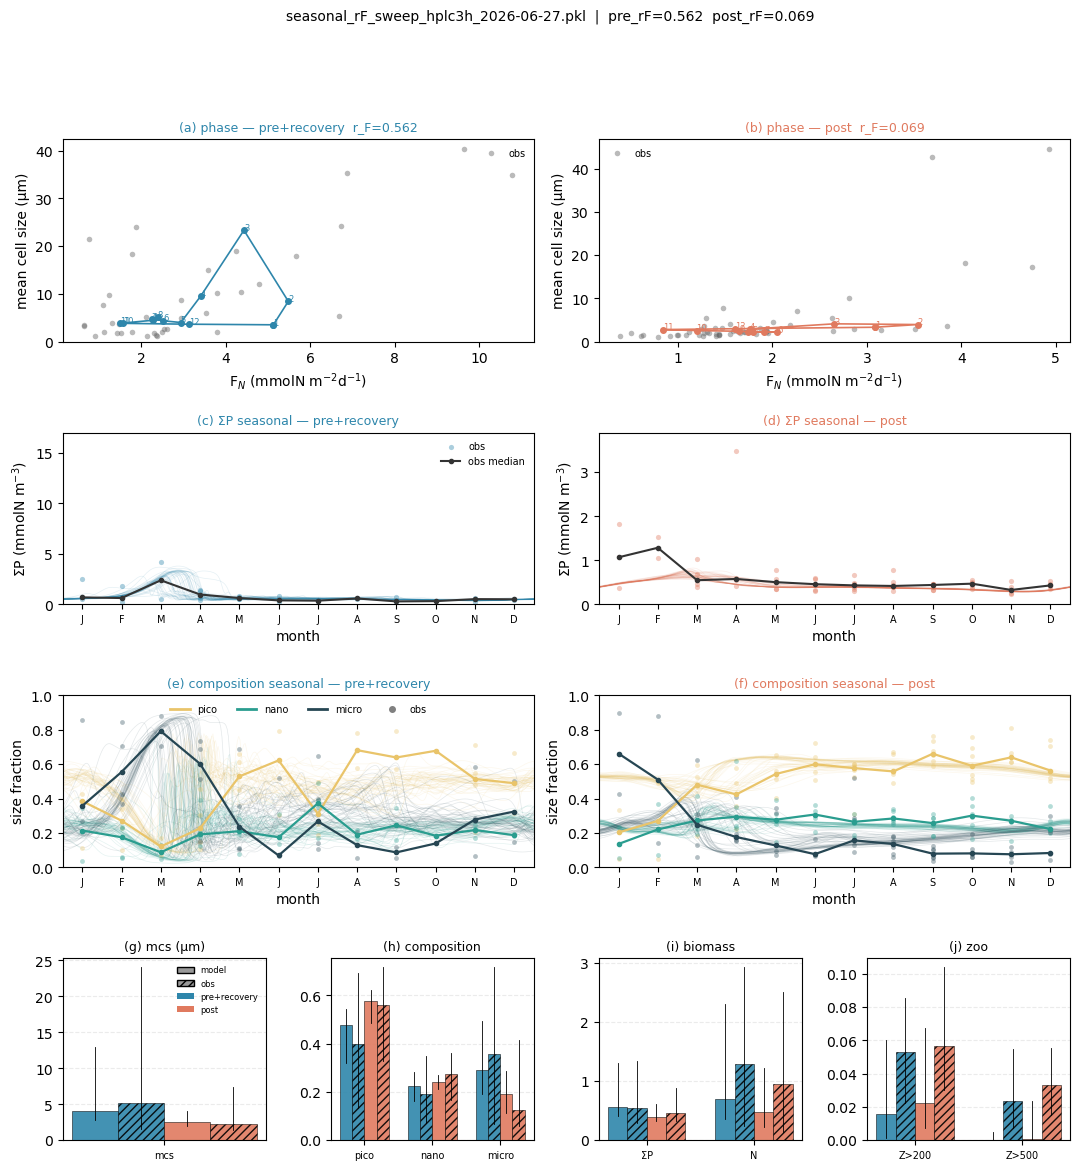

selection: seasonal_rF_sweep_hplc3h_2026-06-27.pkl | pre_rF=0.562 post_rF=0.069
metric   pre_mod  pre_obs post_mod post_obs
mcs        4.136    5.137    2.585    2.318
micro      0.292    0.357    0.191    0.124
sumP       0.570    0.550    0.390    0.459
N          0.705    1.286    0.477    0.959
Z200       0.016    0.053    0.022    0.057
  pre+recovery   ΣP bloom: model=M  obs=M
  post           ΣP bloom: model=M  obs=F
  Z200 inversion (post−pre, median monthly): +0.0062


In [29]:
# ═══ Fig-4 overview (run AFTER the driver header: needs runs, FISH, ERAS, PICKLE_IDX) ═══
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _MID_MONTH_DOY

SPINUP = 15
_MO = np.arange(1, 13); MO = ['J','F','M','A','M','J','J','A','S','O','N','D']
ECOL = {'pre+recovery':'#2E86AB','post':'#E07A5F'}
CLS  = [('pico','#E9C46A'),('nano','#2A9D8F'),('micro','#264653')]
obs_m = ssh.build_obs_monthly(ERAS, forcing_complete=True)

def _clim(r,k):
    keep=r['t']>=SPINUP*365.0
    mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(r['t'][keep],365.0),'right')+1,1,12)
    v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[mo==m]) if np.any(mo==m) else np.nan for m in _MO])
def _vals(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]
    mo=np.clip(np.searchsorted(ssh._MEDGES,np.mod(t,365.0),'right')+1,1,12)
    yr=(t/365.0).astype(int); v=np.asarray(r[k],float)[keep]
    return np.array([np.nanmean(v[(yr==y)&(mo==m)]) for y in np.unique(yr) for m in _MO if np.any((yr==y)&(mo==m))])
def _daily(r,k):
    keep=r['t']>=SPINUP*365.0; t=r['t'][keep]; v=np.asarray(r[k],float)[keep]
    doy=np.mod(t,365.0); yr=(t/365.0).astype(int); out=[]
    for y in np.unique(yr):
        m=yr==y; o=np.argsort(doy[m]); out.append((doy[m][o],v[m][o]))
    return out
def _d2m(d): return np.interp(d,np.r_[0,_MID_MONTH_DOY,365],np.r_[0.5,_MO.astype(float),12.5])
def _bar(ax,x,vals,c,h=None,w=0.18):
    v=np.asarray(vals,float); v=v[np.isfinite(v)]
    if v.size==0: return
    lo,hi=np.percentile(v,[10,90])
    ax.bar(x,np.median(v),w,color=c,alpha=0.9,hatch=h,edgecolor='k',lw=0.4,zorder=2)
    ax.plot([x,x],[lo,hi],color='k',lw=0.6,zorder=4)

fig=plt.figure(figsize=(13,13))
gs=GridSpec(4,4,figure=fig,height_ratios=[1,0.85,0.85,0.9],hspace=0.5,wspace=0.32)

# Row 0 — phase loops (F_N, mcs)
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[0,col]); c=ECOL[era]; r=runs[era]
    fn,mc=_clim(r,'FN'),_clim(r,'mcs'); o=np.r_[np.arange(12),0]
    ax.plot(fn[o],mc[o],'-o',color=c,lw=1.2,ms=4,zorder=3)
    for m in _MO: ax.annotate(str(m),(fn[m-1],mc[m-1]),fontsize=6,color=c,zorder=5)
    om=obs_m[era].dropna(subset=['FN','mcs'])
    ax.scatter(om['FN'],om['mcs'],s=16,color='0.4',alpha=0.45,lw=0,zorder=2,label='obs')
    ax.set_xlabel('F$_N$ (mmolN m$^{-2}$d$^{-1}$)'); ax.set_ylabel('mean cell size (µm)'); ax.set_ylim(bottom=0)
    ax.set_title(f"({'ab'[ERAS.index(era)]}) phase — {era}  r_F={FISH[era]:.3f}",fontsize=9,color=c); ax.legend(fontsize=7,frameon=False)

# Row 1 — ΣP seasonal (model daily traces + obs dots + obs median)  ← NEW
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[1,col]); r=runs[era]; c=ECOL[era]
    om=obs_m[era].dropna(subset=['sumP'])
    for doy,v in _daily(r,'sumP'): ax.plot(_d2m(doy),v,'-',color=c,alpha=0.12,lw=0.5,zorder=1)
    ax.scatter(om['mo'],om['sumP'],s=14,color=c,alpha=0.4,lw=0,zorder=2,label='obs')
    ax.plot(_MO,om.groupby('mo')['sumP'].median().reindex(_MO).values,'-o',color='0.2',lw=1.5,ms=3,zorder=4,label='obs median')
    allv=np.concatenate([v for _,v in _daily(r,'sumP')]+[om['sumP'].to_numpy()])
    ax.set_xlim(0.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7)
    ax.set_ylim(0,np.nanpercentile(allv,98)*5.55)            # clip lone bloom spike so obs stays visible
    ax.set_xlabel('month'); ax.set_ylabel('ΣP (mmolN m$^{-3}$)')
    ax.set_title(f"({'cd'[ERAS.index(era)]}) ΣP seasonal — {era}",fontsize=9,color=c)
    if col.start==0: ax.legend(fontsize=7,frameon=False)

# Row 2 — seasonal composition
for col,era in zip([slice(0,2),slice(2,4)],ERAS):
    ax=fig.add_subplot(gs[2,col]); r=runs[era]; om=obs_m[era]
    for cls,cc in CLS:
        for doy,v in _daily(r,cls): ax.plot(_d2m(doy),v,'-',color=cc,alpha=0.12,lw=0.5,zorder=1)
        o=om.dropna(subset=[cls]); ax.scatter(o['mo'],o[cls],s=12,color=cc,alpha=0.35,lw=0,zorder=2)
        ax.plot(_MO,o.groupby('mo')[cls].median().reindex(_MO).values,'-o',color=cc,lw=1.6,ms=3,zorder=4)
    ax.set_xlim(0.5,12.5); ax.set_xticks(_MO); ax.set_xticklabels(MO,fontsize=7); ax.set_ylim(0,1)
    ax.set_xlabel('month'); ax.set_ylabel('size fraction')
    ax.set_title(f"({'ef'[ERAS.index(era)]}) composition seasonal — {era}",fontsize=9,color=ECOL[era])
    if col.start==0:
        ax.legend([Line2D([],[],color=cc,lw=2) for _,cc in CLS]+[Line2D([],[],color='.5',marker='o',ls='',ms=4)],
                  [c for c,_ in CLS]+['obs'],fontsize=7,frameon=False,ncol=4,loc='upper center')

# Row 3 — model vs obs bars (median + 10–90%)
BP=[('(g) mcs (µm)',[('mcs','mcs')]),('(h) composition',[('pico','pico'),('nano','nano'),('micro','micro')]),
    ('(i) biomass',[('ΣP','sumP'),('N','N')]),('(j) zoo',[('Z>200','Z200'),('Z>500','Z500')])]
W=0.18; OFF={('pre+recovery','m'):-1.5*W,('pre+recovery','o'):-0.5*W,('post','m'):0.5*W,('post','o'):1.5*W}
for j,(title,metrics) in enumerate(BP):
    ax=fig.add_subplot(gs[3,j])
    for i,(lab,key) in enumerate(metrics):
        for era in ERAS:
            c=ECOL[era]
            _bar(ax,i+OFF[(era,'m')],_vals(runs[era],key),c,None,W)
            obs=obs_m[era][key].dropna().to_numpy() if key in obs_m[era].columns else np.array([])
            _bar(ax,i+OFF[(era,'o')],obs,c,'////',W)
    ax.set_xticks(range(len(metrics))); ax.set_xticklabels([m[0] for m in metrics],fontsize=7)
    ax.set_title(title,fontsize=9); ax.set_ylim(bottom=0); ax.grid(axis='y',ls='--',alpha=0.25)
    if j==0:
        ax.legend([Patch(fc='.6',ec='k'),Patch(fc='.6',ec='k',hatch='////')]+[Patch(fc=ECOL[e]) for e in ERAS],
                  ['model','obs']+list(ERAS),fontsize=6,frameon=False)

fig.suptitle(f"{PICKLES[PICKLE_IDX]}  |  pre_rF={FISH['pre+recovery']:.3f}  post_rF={FISH['post']:.3f}",fontsize=10)
plt.show()

# ── numeric overview ──
print(f"selection: {PICKLES[PICKLE_IDX]} | pre_rF={FISH['pre+recovery']:.3f} post_rF={FISH['post']:.3f}")
print(f"{'metric':<7}{'pre_mod':>9}{'pre_obs':>9}{'post_mod':>9}{'post_obs':>9}")
for lab,key in [('mcs','mcs'),('micro','micro'),('sumP','sumP'),('N','N'),('Z200','Z200')]:
    rr=[]
    for era in ERAS:
        rr+=[np.nanmedian(_vals(runs[era],key)),
             np.nanmedian(obs_m[era][key].dropna().to_numpy()) if key in obs_m[era].columns else np.nan]
    print(f"{lab:<7}{rr[0]:>9.3f}{rr[1]:>9.3f}{rr[2]:>9.3f}{rr[3]:>9.3f}")
for era in ERAS:
    bm=int(np.nanargmax(_clim(runs[era],'sumP')))+1
    ob=obs_m[era].dropna(subset=['sumP']).groupby('mo')['sumP'].median().reindex(_MO).values
    print(f"  {era:<14} ΣP bloom: model={MO[bm-1]}  obs={MO[int(np.nanargmax(ob))]}")
print(f"  Z200 inversion (post−pre, median monthly): "
      f"{np.nanmedian(_vals(runs['post'],'Z200'))-np.nanmedian(_vals(runs['pre+recovery'],'Z200')):+.4f}")

══ A1 — post monthly MEDIAN by product (peak month + total n) ══
product                J     F     M     A     M     J     J     A     S     O     N     D  peak    n
─────────────────────────────────────────────────────────────────────────────────────────────────────
HPLC Σ(size)        1.43  1.05  0.55  0.55  0.54  0.33  0.43  0.43  0.44  0.46  0.33  0.43     J   64
HPLC micro          1.09  0.21  0.14  0.11  0.10  0.02  0.06  0.04  0.03  0.03  0.03  0.04     J   64
HPLC TotChlA        1.43  1.05  0.55  0.55  0.54  0.33  0.43  0.43  0.44  0.46  0.33  0.43     J   64
niskin (mmolN)      0.76  1.02  0.32  0.26  0.16  0.12  0.17  0.15  0.14  0.16  0.10  0.18     F   89
niskin (mg m⁻³)     1.22  1.62  0.51  0.42  0.26  0.19  0.28  0.24  0.22  0.25  0.16  0.28     F   89
n per month (HPLC micro): [4, 3, 5, 5, 6, 5, 6, 7, 7, 7, 4, 5]


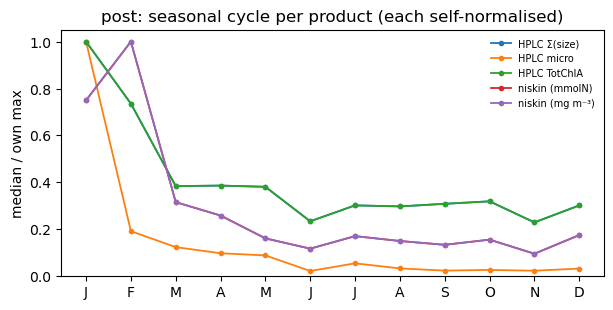


══ A2 — every post sample in ['J', 'F'] (sorted by micro) ══
      date  mo regime_adjusted  micro_mmolN  HPLC_sumP  TotChlA_mmolN  Chl_niskin_mmolN  FN_mmolN_m2_d  depth_cutoff    Temp_C  NO3_mmolN
2012-01-01   1      transition     1.637052   1.823314       1.823314          1.916887       4.924833     29.700000 24.433369   0.298791
2011-01-01   1         relaxed     1.478984   1.787832       1.787832          1.855139            NaN     31.570408 24.905265   4.711356
2011-02-01   2       upwelling     1.339164   1.520910       1.520910          1.620484       3.689925     24.543292 23.952628   1.494728
2009-01-01   1         relaxed     0.707131   1.068596       1.068596          1.080919       4.035741     29.478446 24.785016   0.313384
2009-02-01   2       upwelling     0.210074   0.606280       0.606280          0.474496            NaN     47.005907       NaN   5.186724
2008-01-01   1         relaxed     0.158529   0.369353       0.369353          0.226504       1.473547     48.

In [25]:
# ══ A1+A2: which product blooms when, and is one January sample driving it? ══
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seasonal_scan_harness as ssh

ERA, WIN = 'post', [1, 2]                 # era + months to scrutinise (Jan, Feb)
MO = ['J','F','M','A','M','J','J','A','S','O','N','D']

df = pd.read_csv(ssh.DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = df['date'].dt.year.map(ssh.ERA_OF); df['mo'] = df['date'].dt.month
binc = ['pico_mmolN','nano_mmolN','micro_mmolN']
df['HPLC_sumP'] = df[binc].sum(axis=1, min_count=1)

PRODS = {'HPLC_sumP':'HPLC Σ(size)','micro_mmolN':'HPLC micro','TotChlA_mmolN':'HPLC TotChlA',
         'Chl_niskin_mmolN':'niskin (mmolN)','Chl_niskin_mgm3':'niskin (mg m⁻³)'}
miss = [k for k in PRODS if k not in df.columns]
if miss: print("!! columns not found (give me the right names):", miss)
PRODS = {k:v for k,v in PRODS.items() if k in df.columns}
post = df[df['era']==ERA]

print(f"══ A1 — {ERA} monthly MEDIAN by product (peak month + total n) ══")
hdr = f"{'product':<18}" + "".join(f"{m:>6}" for m in MO) + f"{'peak':>6}{'n':>5}"; print(hdr); print('─'*len(hdr))
for col,lab in PRODS.items():
    g = post.dropna(subset=[col]).groupby('mo')[col]
    s = g.median().reindex(range(1,13)).values
    pk = MO[int(np.nanargmax(s))] if np.isfinite(s).any() else '·'
    print(f"{lab:<18}" + "".join(f"{v:6.2f}" if np.isfinite(v) else f"{'·':>6}" for v in s) + f"{pk:>6}{int(g.size().sum()):5d}")
print("n per month (HPLC micro):", post.dropna(subset=['micro_mmolN']).groupby('mo').size().reindex(range(1,13)).fillna(0).astype(int).tolist())

fig,ax=plt.subplots(figsize=(7,3.2))
for col,lab in PRODS.items():
    s = post.dropna(subset=[col]).groupby('mo')[col].median().reindex(range(1,13)).values
    if np.isfinite(s).any(): ax.plot(range(1,13), s/np.nanmax(s), '-o', ms=3, lw=1.3, label=lab)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MO); ax.set_ylim(0,1.05); ax.set_ylabel('median / own max')
ax.set_title(f'{ERA}: seasonal cycle per product (each self-normalised)'); ax.legend(fontsize=7,frameon=False); plt.show()

print(f"\n══ A2 — every {ERA} sample in {[MO[m-1] for m in WIN]} (sorted by micro) ══")
cols=[c for c in ['date','mo','regime_adjusted','micro_mmolN','HPLC_sumP','TotChlA_mmolN','Chl_niskin_mmolN',
                  'FN_mmolN_m2_d','depth_cutoff','Temp_C','NO3_mmolN'] if c in post.columns]
sub = post[post['mo'].isin(WIN)][cols].sort_values('micro_mmolN', ascending=False)
print(sub.to_string(index=False))
mser = post.dropna(subset=['micro_mmolN'])
pk_full = MO[int(np.nanargmax(mser.groupby('mo')['micro_mmolN'].median().reindex(range(1,13)).values))]
top = mser.loc[mser['micro_mmolN'].idxmax()]
pk_loo = MO[int(np.nanargmax(mser.drop(mser['micro_mmolN'].idxmax()).groupby('mo')['micro_mmolN'].median().reindex(range(1,13)).values))]
print(f"\nHPLC micro peak: full record={pk_full}  →  drop biggest sample ({top['date'].date()}, "
      f"micro={top['micro_mmolN']:.3f}) → {pk_loo}   (same month ⇒ not a single-sample artefact)")

In [26]:
# ══ A3: post Jan/Feb vs reference — ranked anomaly across EVERY numeric obs column ══
import numpy as np, pandas as pd
from scipy.stats import mannwhitneyu
import seasonal_scan_harness as ssh

ERA, WIN = 'post', [1, 2]
REF = 'all'      # 'all' | 'same_era' (post other months) | 'same_months' (Jan/Feb other eras)

df = pd.read_csv(ssh.DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = df['date'].dt.year.map(ssh.ERA_OF); df['mo'] = df['date'].dt.month
mask = (df['era']==ERA) & (df['mo'].isin(WIN)); sub = df[mask]
rest = {'all': df[~mask],
        'same_era':   df[(df.era==ERA) & (~df.mo.isin(WIN))],
        'same_months':df[(df.mo.isin(WIN)) & (df.era!=ERA)]}[REF]
print(f"window: {ERA} {[ 'JFMAMJJASOND'[m-1] for m in WIN]}  n={len(sub)}  vs REF='{REF}' n={len(rest)}")

rows=[]
for c in [c for c in df.select_dtypes('number').columns if c != 'mo']:
    a=sub[c].dropna().to_numpy(); b=rest[c].dropna().to_numpy()
    if len(a)<2 or len(b)<5: continue
    iqr=np.subtract(*np.percentile(b,[75,25]))
    shift=(np.median(a)-np.median(b))/iqr if iqr>0 else np.nan
    try: p=mannwhitneyu(a,b,alternative='two-sided').pvalue
    except Exception: p=np.nan
    rows.append(dict(column=c, n_win=len(a), med_win=np.median(a), med_rest=np.median(b), robust_shift=shift, p=p))
T=pd.DataFrame(rows); T['mag']=T.robust_shift.abs(); T=T.sort_values('mag',ascending=False)
pd.set_option('display.float_format', lambda x:f"{x:.3g}")
print("\nranked by |robust_shift| (median diff in units of REF IQR):")
print(T.drop(columns='mag').to_string(index=False))
print("\nforcing drivers:")
print(T[T.column.isin(['FN_mmolN_m2_d','depth_cutoff','Temp_C'])].drop(columns='mag').to_string(index=False))

window: post ['J', 'F']  n=18  vs REF='all' n=237

ranked by |robust_shift| (median diff in units of REF IQR):
                     column  n_win  med_win  med_rest  robust_shift        p
                micro_mmolN      7    0.707    0.0646          3.87 0.000783
              TotChlA_mmolN      7     1.07     0.474          2.72  0.00424
           Chl_niskin_mmolN     12     0.78     0.211          2.42 8.42e-05
            Chl_niskin_mgm3     12     1.24     0.335          2.42 8.42e-05
               micro_frac_N      7    0.662     0.142          1.93  0.00107
              size_centroid      7     1.26     0.378          1.82 0.000889
          Phaeo_niskin_mgm3     12    0.842     0.368          1.66  0.00015
                 micro_frac      7    0.808     0.266          1.43  0.00114
                pico_frac_N      7    0.203     0.556         -1.41  0.00128
                 nbss_slope      7   -0.914      -1.1          1.32  0.00107
                  slope_2pt      7    0.25